# Phase 3 — Embedding Cluster Visualization
Validating Layer 2 by projecting benign and malicious embeddings into 2D with UMAP.


In [3]:
from pathlib import Path
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from umap.umap_ import UMAP

# Resolve project root whether cwd is repo root, notebooks/, or parent folder
cwd = Path.cwd()
candidates = [cwd, cwd.parent, cwd / "supply-chain-detector"]
PROJECT_ROOT = next((p for p in candidates if (p / "detector").exists()), cwd)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from detector.layer2_embeddings.code_embedder import encode as embed_code
print(f"Using project root: {PROJECT_ROOT}")

Using project root: c:\Users\Mark Christian Anub\Desktop\side projects\supply-chain-detector


In [4]:
data_dir = PROJECT_ROOT / "data" / "processed"

with open(data_dir / "benign_normalized.json", "r", encoding="utf-8") as f:
    benign_data = json.load(f)

with open(data_dir / "malicious_normalized.json", "r", encoding="utf-8") as f:
    malicious_data = json.load(f)

print(f"Benign: {len(benign_data)} records")
print(f"Malicious: {len(malicious_data)} records")

Benign: 40 records
Malicious: 5 records


In [5]:
def embed_dataset(records, label):
    """Embed source code from each record, return vectors and labels."""
    embeddings = []
    labels = []
    names = []
    skipped = 0
    
    for rec in records:
        source = rec.get("source_code", "") or rec.get("source", "")
        if not source or not source.strip():
            skipped += 1
            continue
        try:
            vec = embed_code(source)
            embeddings.append(vec)
            labels.append(label)
            names.append(rec.get("name", "unknown"))
        except Exception:
            skipped += 1
    
    print(f"  [{label}] Embedded {len(embeddings)}, skipped {skipped}")
    return embeddings, labels, names


print("Embedding benign samples...")
ben_embs, ben_labels, ben_names = embed_dataset(benign_data, "benign")
print("Embedding malicious samples...")
mal_embs, mal_labels, mal_names = embed_dataset(malicious_data, "malicious")


Embedding benign samples...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [benign] Embedded 40, skipped 0
Embedding malicious samples...
  [malicious] Embedded 0, skipped 5


In [6]:
# Combine all embeddings into one matrix
all_embs = np.vstack(ben_embs + mal_embs).astype(np.float32)
all_labels = ben_labels + mal_labels

print(f"Total embedding matrix shape: {all_embs.shape}")


Total embedding matrix shape: (40, 384)


In [7]:
# UMAP reduces 384-dimensional vectors → 2 dimensions for plotting
reducer = UMAP(
    n_components=2,          # ← 2D output
    random_state=42,          # ← fixed seed for reproducibility
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",             
)

coords_2d = reducer.fit_transform(all_embs)

print(f"UMAP output shape: {coords_2d.shape}")


c:\Users\Mark Christian Anub\Desktop\side projects\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output shape: (40, 2)


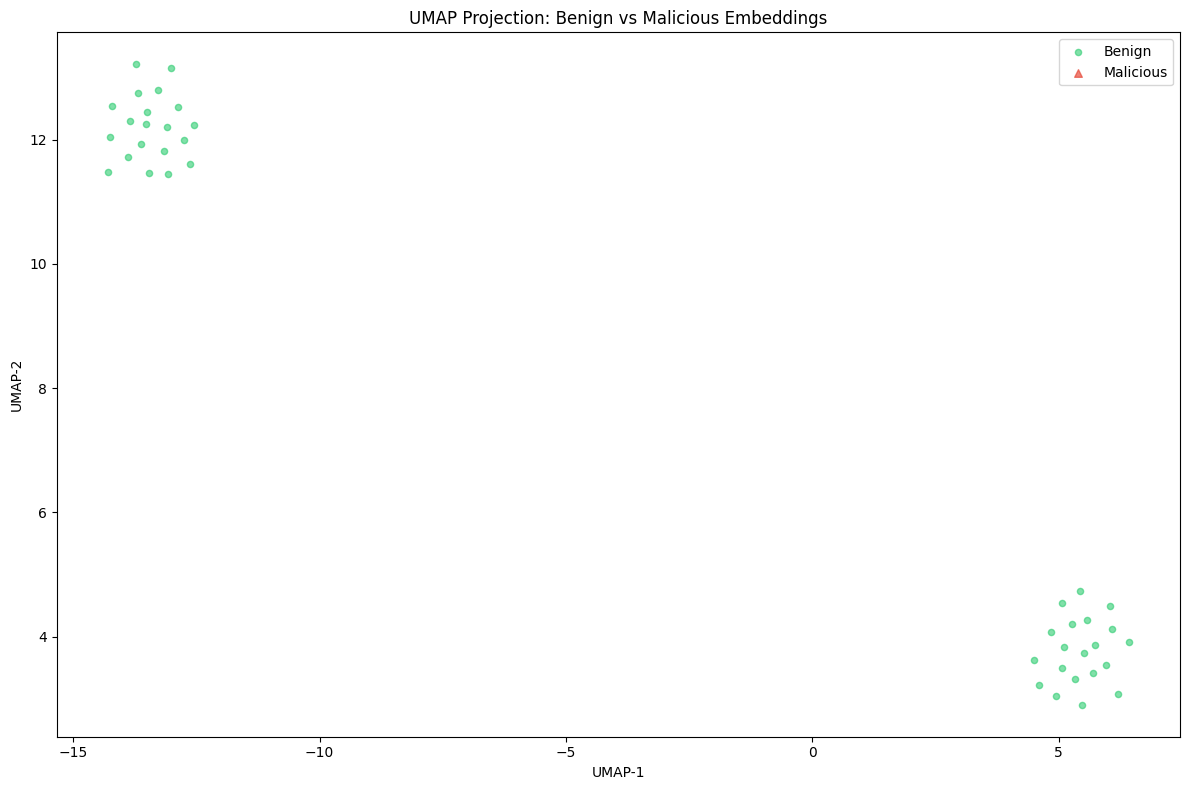

In [8]:
# Separate coordinates by label
benign_mask = [l == "benign" for l in all_labels]
malicious_mask = [l == "malicious" for l in all_labels]

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    coords_2d[benign_mask, 0],      # ← x coordinates
    coords_2d[benign_mask, 1],      # ← y coordinates
    c="#2ecc71",
    label="Benign",
    alpha=0.6,
    s=20,
)

ax.scatter(
    coords_2d[malicious_mask, 0],
    coords_2d[malicious_mask, 1],
    c="#e74c3c",                           # ← red for malicious
    label="Malicious",
    alpha=0.7,
    s=30,
    marker="^",
)

ax.set_title("UMAP Projection: Benign vs Malicious Embeddings")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend()
plt.tight_layout()
plt.show()

## Interpretation

**Key observations:**
- Clusters where benign and malicious clearly separate → Layer 2 adds strong signal
- Overlap zones → these packages need Layer 1 metadata AND Layer 3 code analysis
- Outlier malicious points far from benign → high-confidence Layer 2 detections

**Limitations:**
- Small dataset may not show all real-world patterns
- UMAP is stochastic — layout varies across runs despite seed
- Some malicious packages intentionally mimic benign code patterns

